In [1]:
from extract_features import *

In [2]:
save_path = "Dados/Saída/"

<Axes: >

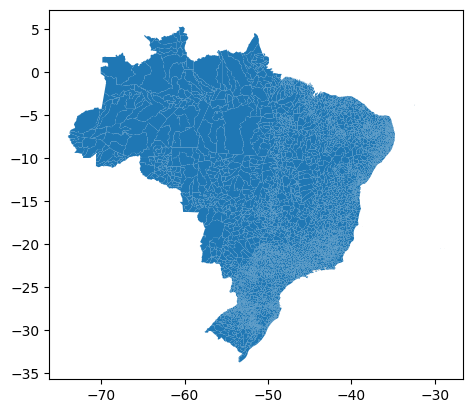

In [3]:
ibge = gpd.read_file("zip://Dados/BR_Municipios_2024.zip!BR_Municipios_2024.shp")
ibge.plot()

<Axes: >

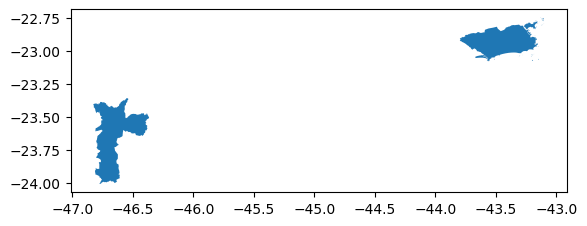

In [4]:
selected_cd_mun = ["3550308", "3304557"]
selected_cd_mun = [str(cd) for cd in selected_cd_mun]

ibge["CD_MUN"] = ibge["CD_MUN"].astype(str)
selected_ibge = ibge.loc[ibge["CD_MUN"].isin(selected_cd_mun)].copy()
selected_ibge.plot()

In [7]:
found_cd_mun = set(selected_ibge["CD_MUN"].astype(str).tolist())
missing_cd_mun = sorted(set(selected_cd_mun) - found_cd_mun)

if missing_cd_mun:
    raise ValueError(f"cd_mun not found in IBGE layer: {missing_cd_mun}")

print(f"Selected municipalities: {sorted(found_cd_mun)}")

Selected municipalities: ['3304557', '3550308']


In [8]:
tags = {
    "amenity": ['school', 'community_centre', 'place_of_worship', 'clinic', 'hospital', 
                'recycling', 'marketplace', 'kitchen', 'restaurant', 'cafe', 
                'fast_food', 'bar', 'bus_station', 'waste_disposal', 'bicycle_parking'],
    "leisure": ['park', 'pitch', 'garden'],
    "shop": ['bakery', 'supermarket', 'convenience'],
    "landuse": ['allotments'],
    "railway": ['station'],
    "public_transport": ['station'],
    "highway": ['bus_stop', 'steps', 'street_lamp'],
    #"footway": ['sidewalk', 'crossing'],
    #"cycleway": ['lane'],
    "water": ['river']
    #"hazard": ['flooding']
}

In [9]:
theme_keys = ["amenity", "leisure", "shop", "landuse", "railway", "public_transport", "highway", "water"]

for _, mun in selected_ibge.iterrows():
    cd_mun = str(mun["CD_MUN"])
    city_geom = selected_ibge.loc[[mun.name]]
    print(f"Processing municipality cd_mun={cd_mun} (core themes)")

    for key in theme_keys:
        process_key(
            key=key,
            tags=tags,
            city_geom=city_geom,
            save_path=save_path,
            columns_to_show=[key, "name"],
            cd_mun=cd_mun,
            theme_name=key
        )

Processing municipality cd_mun=3550308 (core themes)

Processing amenity for cd_mun=3550308...
Buscando por features com a tag 'amenity': 
['school', 'community_centre', 'place_of_worship', 'clinic', 'hospital', 'recycling', 'marketplace', 'kitchen', 'restaurant', 'cafe', 'fast_food', 'bar', 'bus_station', 'waste_disposal', 'bicycle_parking']

Quantidade original de features: 12936

Geometrias encontradas:
  - Polygons/MultiPolygons: 7019
  - Lines/MultiLines: 0

-> 8750 features mantidas dentro dos limites da cidade após processamento.

Map saved: docs/mapas/3550308/amenity/features_map.html
Parquet saved: Dados/Saída/amenity/features_3550308.parquet
PMTiles saved: Dados/Saída/amenity/features_3550308.pmtiles
✓ Completed amenity


Processing leisure for cd_mun=3550308...
Buscando por features com a tag 'leisure': 
['park', 'pitch', 'garden']

Quantidade original de features: 15005

Geometrias encontradas:
  - Polygons/MultiPolygons: 14855
  - Lines/MultiLines: 0

-> 11051 features man

/home/gil/github/etl_osm/.venv/lib/python3.12/site-packages/pyogrio/raw.py:733: RuntimeWarning: At least one tile exceeded the default maximum tile size of 500000 bytes and was encoded at lower resolution
  ogr_write(


PMTiles saved: Dados/Saída/highway/features_3550308.pmtiles
✓ Completed highway


Processing water for cd_mun=3550308...
Buscando por features com a tag 'water': 
['river']

Quantidade original de features: 74

Geometrias encontradas:
  - Polygons/MultiPolygons: 73
  - Lines/MultiLines: 1

-> 34 features mantidas dentro dos limites da cidade após processamento.

Map saved: docs/mapas/3550308/water/features_map.html
Parquet saved: Dados/Saída/water/features_3550308.parquet
PMTiles saved: Dados/Saída/water/features_3550308.pmtiles
✓ Completed water

Processing municipality cd_mun=3304557 (core themes)

Processing amenity for cd_mun=3304557...
Buscando por features com a tag 'amenity': 
['school', 'community_centre', 'place_of_worship', 'clinic', 'hospital', 'recycling', 'marketplace', 'kitchen', 'restaurant', 'cafe', 'fast_food', 'bar', 'bus_station', 'waste_disposal', 'bicycle_parking']

Quantidade original de features: 10524

Geometrias encontradas:
  - Polygons/MultiPolygons: 2485
  -

ArrowInvalid: ("Could not convert 'P8893' with type str: tried to convert to int64", 'Conversion failed for column id with type object')

In [ ]:
# Define bike infrastructure tags matching Overpass query
# Organized by categorization: Ciclovias (track) / Ciclofaixas (lane) / 
# Calçadas compartilhadas (sidepath + footway/pedestrian + bicycle) / Ciclorrotas (buffered_lane, shared_lane, share_busway)

bike_tags = {
    
    "highway": [
        # CICLOVIAS - Protected cycleways
        "cycleway",
        # CALÇADAS COMPARTILHADAS - Shared sidewalks
        "footway", 
        "pedestrian"
        ],
    
    "cycleway": [
        # CICLOVIAS - Protected cycleways (track)
        "track", 
        "opposite_track",
        # CICLOFAIXAS - Marked cycleways (lane)
        "lane", 
        "opposite_lane",
        # CALÇADAS COMPARTILHADAS - Shared paths
        "sidepath",
        # CICLORROTAS - Shared lanes with preference
        "buffered_lane",
        "shared_lane", 
        "share_busway",
        "opposite_share_busway"
    ],
    
    # Directional cycleway tags (left, right, both)
    "cycleway:left": [
        "track", 
        "opposite_track",
        "lane", 
        "opposite_lane",
        "shared_lane", 
        "share_busway",
        "buffered_lane",
        "sidepath"
    ],
    
    "cycleway:right": [
        "track", 
        "opposite_track",
        "lane", 
        "opposite_lane",
        "shared_lane", 
        "share_busway",
        "buffered_lane",
        "sidepath"
    ],
    
    "cycleway:both": ["lane"],
    
    # CALÇADAS COMPARTILHADAS - Shared sidewalks
    "bicycle": ["designated", "yes"]
}

In [ ]:
for _, mun in selected_ibge.iterrows():
    cd_mun = str(mun["CD_MUN"])
    city_geom = selected_ibge.loc[[mun.name]]
    print(f"Processing municipality cd_mun={cd_mun} (bike_tags)")

    process_key(
        tags=bike_tags,
        city_geom=city_geom,
        save_path=save_path,
        columns_to_show=['highway', 'bicycle', 'bicycle_road', 'cyclestreet', 'cycleway', 'cycleway:left', 'cycleway:right', 'cycleway:both', 'name'],
        tags_name="bike_tags",
        use_custom_type=True,
        cd_mun=cd_mun,
        theme_name="bike_tags"
    )


Processing all tags (bike_tags)...
Buscando por features para todas as tags...

Quantidade original de features: 54833

Geometrias encontradas:
  - Polygons/MultiPolygons: 178
  - Lines/MultiLines: 53455

-> 38382 features mantidas dentro dos limites da cidade após processamento.

Map saved: docs/mapas/features_map_bike_tags.html
Parquet saved: Dados/Saída/features_bike_tags.parquet
PMTiles saved: Dados/Saída/features_bike_tags.pmtiles
✓ Completed processing all tags



c:\Users\gilne\OneDrive\Documentos\Github\etl_osm\.venv\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: At least one tile exceeded the default maximum tile size of 500000 bytes and was encoded at lower resolution
  ogr_write(


In [ ]:
footway_tags = {
    "highway": ["footway", "pedestrian", "corridor"],#, "path", "steps"],
    "footway": ["sidewalk", "crossing"],
    "foot": ["designated", "yes"],
    "sidewalk": ["yes","both","left","right"],
    #"area:highway": ["footway"],
    #"area": ["yes"],
    "informal": ["yes"]
}

In [ ]:
for _, mun in selected_ibge.iterrows():
    cd_mun = str(mun["CD_MUN"])
    city_geom = selected_ibge.loc[[mun.name]]
    print(f"Processing municipality cd_mun={cd_mun} (footway_tags)")

    process_key(
        tags=footway_tags,
        city_geom=city_geom,
        save_path=save_path,
        columns_to_show=['highway', 'footway', 'foot', 'sidewalk', 'informal', 'name'],
        tags_name="footway_tags",
        use_custom_type=True,
        custom_type='footway',
        cd_mun=cd_mun,
        theme_name="footway_tags"
    )


Processing all tags (footway_tags)...
Buscando por features para todas as tags...

Quantidade original de features: 59322

Geometrias encontradas:
  - Polygons/MultiPolygons: 204
  - Lines/MultiLines: 58897

-> 41049 features mantidas dentro dos limites da cidade após processamento.

Map saved: docs/mapas/features_map_footway_tags.html
Parquet saved: Dados/Saída/features_footway_tags.parquet


c:\Users\9837292\Documents\GitHub\etl_osm\.venv\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: At least one tile exceeded the default maximum tile size of 500000 bytes and was encoded at lower resolution
  ogr_write(


PMTiles saved: Dados/Saída/features_footway_tags.pmtiles
✓ Completed processing all tags



geometry  \
element id                                                              
node    568216724                         POINT (-46.71177 -23.57524)   
        568895346                         POINT (-46.71244 -23.56329)   
        656077030                          POINT (-46.67295 -23.5575)   
        764735650                         POINT (-46.72516 -23.55472)   
        859194325                          POINT (-46.65827 -23.5601)   
...                                                               ...   
way     1496331469  LINESTRING (-46.64285 -23.54804, -46.64291 -23...   
        1496331775  LINESTRING (-46.64267 -23.54815, -46.64272 -23...   
        1496373292  LINESTRING (-46.53925 -23.53115, -46.53898 -23...   
        1496373293  LINESTRING (-46.53925 -23.53115, -46.53972 -23...   
        1496373296                        POINT (-46.53908 -23.53092)   

                       highway maxspeed         crossing crossing:markings  \
element id                                                                   
node    568216724          NaN      NaN              NaN               NaN   
        568895346          NaN      NaN              NaN               NaN   
        656077030          NaN      NaN              NaN               NaN   
        764735650          NaN      NaN              NaN               NaN   
        859194325          NaN      NaN              NaN               NaN   
...                        ...      ...              ...               ...   
way     1496331469     footway      NaN  traffic_signals               NaN   
        1496331775     footway      NaN              NaN               NaN   
        1496373292     footway      NaN              NaN               NaN   
        1496373293     footway      NaN              NaN               NaN   
        1496373296  pedestrian      NaN              NaN               NaN   

                   crossing_ref button_operated traffic_signals:sound  \
element id                                                              
node    568216724           NaN             NaN                   NaN   
        568895346           NaN             NaN                   NaN   
        656077030           NaN             NaN                   NaN   
        764735650           NaN             NaN                   NaN   
        859194325           NaN             NaN                   NaN   
...                         ...             ...                   ...   
way     1496331469          NaN             NaN                   NaN   
        1496331775          NaN             NaN                   NaN   
        1496373292          NaN             NaN                   NaN   
        1496373293          NaN             NaN                   NaN   
        1496373296          NaN             NaN                   NaN   

                   traffic_signals:vibration traffic_signals  ...  \
element id                                                    ...   
node    568216724                        NaN             NaN  ...   
        568895346                        NaN             NaN  ...   
        656077030                        NaN             NaN  ...   
        764735650                        NaN             NaN  ...   
        859194325                        NaN             NaN  ...   
...                                      ...             ...  ...   
way     1496331469                       NaN             NaN  ...   
        1496331775                       NaN             NaN  ...   
        1496373292                       NaN             NaN  ...   
        1496373293                       NaN             NaN  ...   
        1496373296                       NaN             NaN  ...   

                   sidewalk:left:wheelchair sidewalk:left:bicycle  \
element id                                                          
node    568216724                       NaN                   NaN   
        568895346                       N